# Lecture 11a — Simple linear regression and the three Python APIs

We predict a continuous number from **one** input feature using the most-used model in applied statistics:  
Ordinary Least Squares (OLS).  

The mathematics is one library-independent thing; the Python ecosystem offers **three** popular APIs for it, each with its own usability.

## Three places this exact recipe shows up in industry

1. **Real-estate price from one feature.**   
A first-pass valuation of an apartment from square metres alone — coarse, but a real baseline that brokers, valuation tools, and tax assessors all rely on before adding more features.  
2. **Supply-chain demand vs price.**  
Price elasticity: how many fewer (or more) units do we sell for each €1 change in price? A single-feature regression of `units_sold` on `price` is one of the most common business regressions.  
3. **Insurance premium vs one risk factor.**  
Back-of-envelope pricing for car insurance from driver age, or for health insurance from BMI. Real pricing uses many features (Lecture 11b's job) — but a single-feature regression makes the *shape* of the relationship visible first.

All three have a **continuous** target (a euro amount or a quantity), the target is known on past observations, and the new observation genuinely needs a numerical prediction..

## What this notebook covers

1. Load and visualise the tiny one-feature dataset (`temp_to_coffee.csv`).
2. Fit the model with **statsmodels** — the inference-flavoured library; rich `.summary()` table.
3. Fit the same model with **pingouin** — the tabular library; returns a DataFrame you can pipe.
4. Fit the same model with **scikit-learn** — the prediction-flavoured library; `.fit()` / `.predict()` / `.score()`.
5. **Compare the three** side by side: same numbers, three different presentations; *when to reach for which*.
6. Pointers to the canonical documentation pages.
7. A residual diagnostic to close the loop.

## Why three?

Each library is best at one specific job. After this notebook the rest of Lecture 11 uses **scikit-learn only**, because the course's later focus is *predictive* (train/test, regularisation, polynomial features, pipelines). Knowing that statsmodels and pingouin exist — and what they are best at — means you can switch to them when the job is *inferential* (formal stats reports, confidence intervals, hypothesis tests).

## A note on what is *not* here

We deliberately do not hold out a test set.   
With only 20 observations, any 30 % test slice (6 rows) is too small to give a stable generalisation estimate — a single outlier can swing the test R² by 0.4.   
The honest answer on a dataset this small is "fit on everything, eyeball the residuals".

## Where this fits in Lecture 11

- **11a** (this notebook) — one feature, three APIs, the comparison.
- **11b** — many features, the three-way split discipline, the intercept aside; **scikit-learn only**.
- **11c** — what the coefficients actually mean (and the classic pitfalls of getting them wrong).
- **11d** — polynomial regression and regularization (Ridge, Lasso) when the truth is not a straight line.


## Setup

## Install necessary packages with activated virtual environment

### `python -m pip install statsmodels pingouin`

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# API 1 — statsmodels (inference-flavoured)
import statsmodels.api as sm

# API 2 — pingouin (tabular output, built on top of statsmodels + scipy)
import pingouin as pg

# API 3 — scikit-learn (prediction-flavoured)
from sklearn.linear_model import LinearRegression

# General-purpose stats helper (for the residual QQ plot)
from scipy import stats

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")


## 1. Load the data — temperature → coffee quantity

A small teaching dataset: 20 observations of temperature (column `X`, in °C) and a coffee quantity (column `Y`).   
The CSV ships with bare `X` / `Y` headers and no documented units on `Y` — depending on the source the quantity may be daily cups sold at a shop, daily kilograms produced at a roastery, or a related count.   
The mechanics of OLS fit are identical. What changes is the *story* you tell with the slope.
First, rename the columns to something readable. **Always do this** — variable names like `X` and `Y` make notebooks unreadable.

In [7]:
df = pd.read_csv("temp_to_coffee.csv")
df = df.rename(columns={"X": "temperature", "Y": "quantity"})
df.head()

,temperature,quantity
0,20,396
1,22,297
2,23,397
3,18,425
4,19,425


In [8]:
df.describe().round(2)

,temperature,quantity
count,20.00,20.00
mean,19.40,399.30
std,2.87,84.11
min,15.00,250.00
25%,17.75,344.75
50%,19.50,409.50
75%,21.25,448.75
max,25.00,520.00


## 2. Visualise first — always

Before any model fitting, plot the data.   
The eye spots curves, outliers, and clusters far faster than any test statistic.   
A scatter that looks like a clean line is a strong hint that linear regression will do well.   
A scatter that looks like a U-shape says you need polynomial features (`lec_11e`) or a different model.

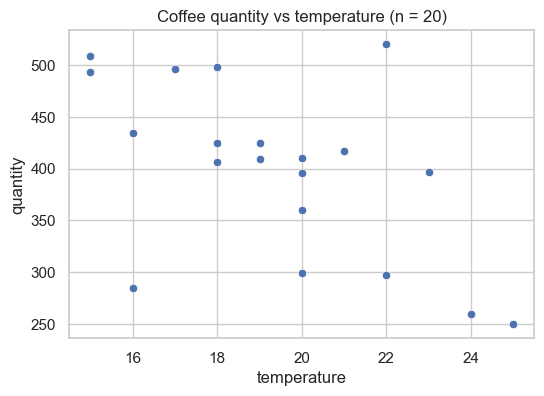

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=df, x="temperature", y="quantity", ax=ax)
ax.set_title("Coffee quantity vs temperature (n = 20)")
plt.show()

## 3. API 1 — `statsmodels` (the inference-flavoured library)

`statsmodels` is the Python home of formal regression statistics:
- OLS, 
- GLMs, 
- time-series models, 
- hypothesis tests.   

Its OLS output is a multi-section `.summary()` table that reads like the appendix of an econometrics paper:
- R², 
- coefficients with standard errors,
- t-statistics,
- p-values, 
- F-statistic, 
- AIC/BIC, 
- residual diagnostics.   

If your job is to *write a statistics report*, this is the library.

Two API quirks to remember:

- The intercept is **not added automatically**. You call `sm.add_constant(X)` to prepend a column of ones.    

Forgetting this is one of the most common bugs; the model fits without an intercept (forcing the line through zero), and the coefficients silently become wrong. See `lec_11c §D2` for the full aside on why removing the intercept is almost always a bad idea.  

**Note**:  
`statsmodels` follows the **`(endog, exog)`** convention — target first, features second. The opposite of scikit-learn's `(X, y)`.

In [10]:
X = df[["temperature"]]
y = df["quantity"]

X_with_const = sm.add_constant(X)
sm_model = sm.OLS(y, X_with_const).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:               quantity   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     7.963
Date:                Tue, 19 May 2026   Prob (F-statistic):             0.0113
Time:                        20:43:34   Log-Likelihood:                -112.85
No. Observations:                  20   AIC:                             229.7
Df Residuals:                      18   BIC:                             231.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         713.8571    112.629      6.338      

### How to read the summary

The cells of the OLS summary that you actually use day to day:

- **`R-squared`** — fraction of variance in `y` explained by `X`. 0 means the model is no better than predicting the mean; 1 means the line passes through every point. Beware: R² always rises when you add features, even useless ones.
- **`coef` of `temperature`** — change in `quantity` per 1 °C change in `temperature`, *holding the constant fixed*. (Read the sign carefully — on this dataset the slope is **negative**, so quantity drops as temperature rises.) In a one-feature model that "holding constant" caveat is trivial; in multiple regression it is the whole game.
- **`P>|t|`** — the p-value for "this coefficient is distinguishable from 0". Conventionally we call it "significant" below 0.05, but p-values mean less than students are taught they do — see `lec_11d` for the pitfalls.
- **`F-statistic`** and its **`Prob (F-statistic)`** — tests whether *any* feature is useful (vs. the intercept-only baseline). With one feature this duplicates the `coef`'s t-test, but it is essential in multiple regression.

The `Durbin-Watson`, `Jarque-Bera`, `Omnibus`, and `Cond. No.` diagnostics in the lower half are residual-quality and conditioning checks — useful but not the headline numbers.


## 4. Plot the fitted line (with seaborn)

`seaborn.lmplot` fits its own OLS line under the hood (it uses `scipy.stats.linregress`) and adds a 95 % confidence band around it. Comparing the printed `coef` to the visible slope is a good sanity check that the fit is what you think it is.


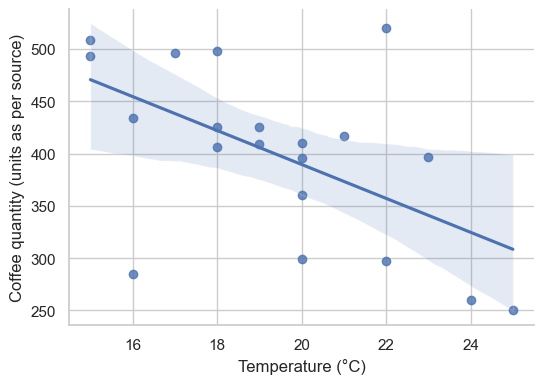

In [11]:
g = sns.lmplot(
    data=df, 
    x="temperature",
    y="quantity",
    height=4, aspect=1.4,
)
g.set_axis_labels("Temperature (°C)", "Coffee quantity (units as per source)")
plt.show()

## 5. API 2 — `pingouin` (the tabular-output library)

[`pingouin`](https://pingouin-stats.org/) is a younger statistics library.
It wraps statsmodels and scipy with a more pandas-friendly interface.
Its `linear_regression` function returns a **DataFrame directly** — useful when you want to:

- pipe results into other pandas operations,
- sort by p-value,
- filter by significance,
- assemble a results table programmatically.

Three API differences from statsmodels:

- The signature is `(X, y)` — features first, like scikit-learn.
- The intercept is added by passing `add_intercept=True`; no separate `add_constant` step.
- The output is a `DataFrame`, indexed by feature name, with columns `coef`, `se`, `T`, `pval`, `r2`, `adj_r2`, plus confidence-interval columns.

The numbers are the **same** as statsmodels' — pingouin is statsmodels under the hood for the OLS itself.


In [12]:
pg_results = pg.linear_regression(X, y, add_intercept=True)
pg_results.round(3)

,names,coef,se,T,pval,r2,adj_r2,CI2.5,CI97.5
0,Intercept,713.857,112.629,6.338,0.000,0.307,0.268,477.232,950.483
1,temperature,-16.214,5.746,-2.822,0.011,0.307,0.268,-28.286,-4.142


In [13]:
# Programmatic access to just the columns we care about.
pg_results[["names", "coef", "pval", "r2"]].round(3)

,names,coef,pval,r2
0,Intercept,713.857,0.000,0.307
1,temperature,-16.214,0.011,0.307


The intercept and slope match the statsmodels summary above to 3 decimal places.
The `r2` and `adj_r2` columns repeat the R² across rows for convenience — every row of the DataFrame carries the full-model statistic.
When you want a single number, grab it from the first row.


## 6. API 3 — `scikit-learn` (the prediction-flavoured library)

`scikit-learn`'s `LinearRegression` is the same OLS, fit the same way, with a different API philosophy.
The class exposes the **fit / predict / score** interface that every estimator in the scikit-learn ecosystem shares — and that uniformity is the killer feature.

The same code shape works for:

- `LinearRegression`,
- `Ridge`,
- `Lasso`,
- `KNeighborsRegressor`,
- `GradientBoostingRegressor`,
- … and a hundred other models.

That is what makes pipelines, cross-validation, and grid search possible.

The trade-off: sklearn does **not** expose p-values, confidence intervals, or formal inference output. By design.

- If you need those → statsmodels.
- If you need predictions, pipelines, regularisation, or anything else in the ML stack → sklearn.

Three API differences from statsmodels:

- The signature is `(X, y)`.
- The intercept is added by the default `fit_intercept=True` — no `add_constant` ritual.
- `X` must be **2-D** (shape `(n, p)`); a 1-D array raises a `ValueError`. We already constructed `X = df[["temperature"]]` as a 2-D DataFrame, which satisfies the shape.


In [18]:
sk_model = LinearRegression().fit(X, y)

print(f"intercept (b0):  {sk_model.intercept_:.3f}")
print(f"slope     (b1):  {sk_model.coef_[0]:.3f}")
print(f"R^2:             {sk_model.score(X, y):.3f}")

intercept (b0):  713.857
slope     (b1):  -16.214
R^2:             0.307


In [19]:
# Predict for three new temperatures we have never seen.
new_temps = pd.DataFrame({"temperature": [15, 20, 25]})
predicted = sk_model.predict(new_temps)
pd.DataFrame({
    "temperature": new_temps["temperature"],
    "predicted_quantity": predicted.round(1),
})

,temperature,predicted_quantity
0,15,470.6
1,20,389.6
2,25,308.5


`.predict()` is what the prediction-flavoured framing buys you:
a fitted model that immediately answers *"what would the quantity be at temperature 15 / 20 / 25?"* by plugging into `ŷ = b₀ + b₁ x`.

The other two APIs can do this too:

- statsmodels: `sm_model.predict(sm.add_constant(new_temps))`
- pingouin: extract coefficients then apply manually

scikit-learn's interface makes it the obvious next step.


## 7. Comparing the three APIs

All three fits should agree to several decimal places. Let us print the coefficients side by side to be sure.


In [20]:
sm_int, sm_slope = sm_model.params["const"], sm_model.params["temperature"]
pg_int   = pg_results.loc[pg_results["names"] == "Intercept",  "coef"].iloc[0]
pg_slope = pg_results.loc[pg_results["names"] == "temperature", "coef"].iloc[0]
sk_int, sk_slope = sk_model.intercept_, sk_model.coef_[0]

comparison = pd.DataFrame({
    "intercept (b0)": [sm_int, pg_int, sk_int],
    "slope (b1)":     [sm_slope, pg_slope, sk_slope],
    "R^2":            [sm_model.rsquared, pg_results["r2"].iloc[0], sk_model.score(X, y)],
}, index=["statsmodels", "pingouin", "scikit-learn"]).round(4)
comparison

,intercept (b0),slope (b1),R^2
statsmodels,713.8571,-16.2143,0.3067
pingouin,713.8571,-16.2143,0.3067
scikit-learn,713.8571,-16.2143,0.3067


Identical to four decimal places — all three run the same closed-form OLS solution.
What differs is the *interface around* the fit.

### When to reach for which

| You need... | Reach for | Why |
| --- | --- | --- |
| A formal statistics report — R², coefficients with std errors, p-values, F-statistic, confidence intervals, residual tests | **statsmodels** | The `.summary()` table is canonical; the whole inference machinery is there. |
| A DataFrame of coefficients you can sort, filter, and pipe into pandas | **pingouin** | Same numbers as statsmodels, presented tidy and ready for `groupby` / `melt` / `merge`. |
| Predictions, regularisation (Ridge, Lasso), polynomial features, pipelines, cross-validation, grid search | **scikit-learn** | The uniform `.fit()` / `.predict()` / `.score()` interface is what the whole ML ecosystem builds on. |
| A one-line regression line on a seaborn scatter plot | **`seaborn.lmplot`** | Convenient — internally calls `scipy.stats.linregress`. Not a substitute when you need numbers. |

You will see all three APIs in production code. **Knowing they exist is the lesson** — the math is identical, so pick by ergonomics.

### The course's convention from here on

Lectures 11b–11e and 13 use **scikit-learn only**. Why:

- They are predictive workflows — train/test splits, regularisation, polynomial features, cross-validation. Sklearn is canonical for these.
- The uniform estimator interface lets us swap `LinearRegression` for `Ridge` for `Lasso` for `KNeighborsRegressor` without rewriting the surrounding code.
- For *inference* questions, refit briefly with statsmodels or pingouin — you already know how.

The reverse is harder: sklearn knows how to fit; statsmodels does not natively do a 10-fold cross-validated grid search.


## 8. Documentation pointers

When you need detail beyond what is in this notebook, go to the source:

**statsmodels**
- OLS class reference: <https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html>
- Linear regression overview (with example workflows): <https://www.statsmodels.org/stable/regression.html>

**pingouin**
- `pingouin.linear_regression` function: <https://pingouin-stats.org/generated/pingouin.linear_regression.html>

**scikit-learn**
- `LinearRegression` class reference: <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html>
- Linear models user guide (includes Ridge, Lasso, ElasticNet, BayesianRidge, etc.): <https://scikit-learn.org/stable/modules/linear_model.html>

Bookmark the linear-models user guide — `lec_11e` and `lec_11f` lean on it heavily for Ridge, Lasso, ElasticNet, and friends.


> ⏱ **Skip if running long.** The brief residuals/QQ check below previews diagnostics that `lec_11b` walks through formally on synthetic violations of all four classical assumptions. If class time is tight, point students at `lec_11b` and skip §9 — they will not lose anything they need for `lec_11c`.


## 9. Residuals — a brief assumption check

OLS makes two assumptions about the residuals (`y − ŷ`):

- they should be roughly **normally distributed** around zero,
- their spread should not depend on the fitted value (**homoscedasticity**).

The residual-vs-fitted plot catches violations:

- a **fan shape** → spread grows with `ŷ` → try a log-transform of `y`,
- a **U-shape** → a linear fit is missing curvature → `lec_11e`'s polynomial features are the cure.

These plots are library-independent — we use residuals from *any* of the three fits above (numerically identical) plus `scipy.stats.probplot` for the QQ plot.
That way the diagnostic is reusable when later notebooks fit with scikit-learn only.


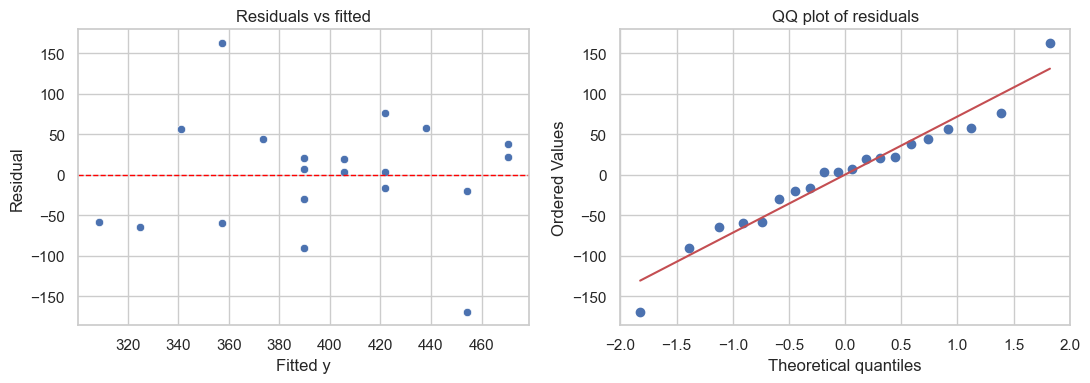

In [12]:
# Residuals from any of the three fits will do; we use the sklearn one.
y_pred = sk_model.predict(X)
resid = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(x=y_pred, y=resid, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted y")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs fitted")

stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("QQ plot of residuals")

plt.tight_layout()
plt.show()

## Recap and what is next

- Three APIs, one mathematical answer. **statsmodels** for inference reports, **pingouin** for tabular output, **scikit-learn** for predictions and the broader ML pipeline.
- All three produced identical numbers to four decimal places on this dataset.
- We checked the OLS residual assumptions with a library-independent plot (scipy + matplotlib).
- We *did not* hold out a test set: with 20 observations, doing so would have produced a noisy, misleading "test R²". The discipline of train/test (and train/val/test) returns in `lec_11c` on a larger dataset.

**Coming next in this lecture (scikit-learn only from here on):**

- **`lec_11c`** — many features at once on `grades_factors.xlsx`. The intercept aside (when is it OK to drop it?). Train/test split. A train-vs-test R² feature-count curve as the overfitting diagnostic.
- **`lec_11d`** — what a coefficient really means in a multiple-regression world, and the classic ways people misread them.
- **`lec_11e`** — when the relationship is not linear: polynomial features, the overfitting they create, and the regularization (Ridge, Lasso) that controls it.
- **`lec_11f`** (optional, career-track) — VIF, ElasticNet, robust regression, Bayesian regression, quantile regression.
